In [1]:
import pickle
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path

DATA_DIR = Path("data")

try:
    with open(DATA_DIR / "series_list.pkl", "rb") as f:
        series_list = pickle.load(f)
    with open(DATA_DIR / "test_sub.pkl", "rb") as f:
        actuals = pickle.load(f)
    with open(DATA_DIR / "all_models.pkl", "rb") as f:
        models = pickle.load(f)
    results_df = pd.read_csv(DATA_DIR / "metrics.csv",
                             index_col="Model")
    print("All files loaded successfully.")
except FileNotFoundError as e:
    print(f"File not found: {e}")
except (pickle.UnpicklingError, EOFError) as e:
    print(f"Corrupted file: {e}")
except Exception as e:
    print(f"Unexpected load error: {e}")

FORECAST_HORIZON = 18

All files loaded successfully.


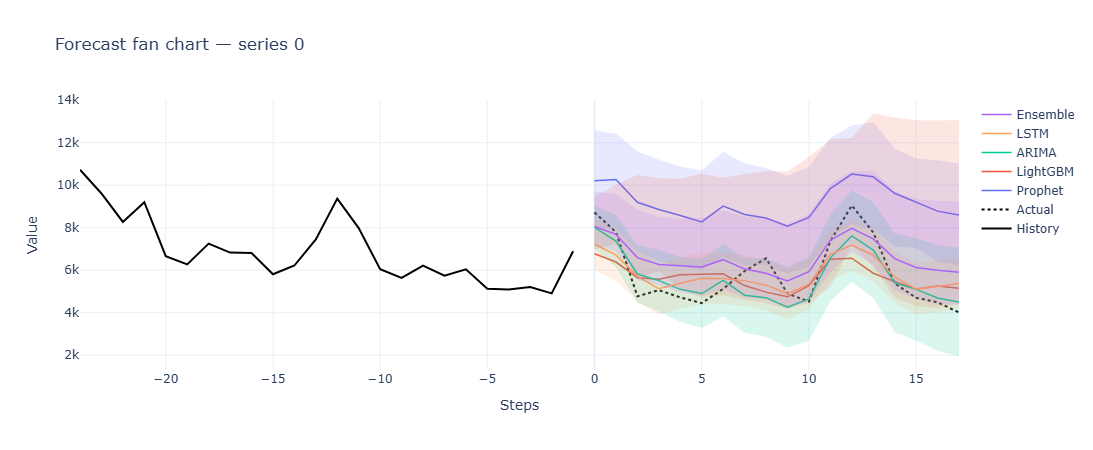

In [2]:
def plot_fan_chart(series_idx=0):
    colors = {
        "Prophet":  ("rgba(99,110,250,0.15)",  "rgb(99,110,250)"),
        "LightGBM": ("rgba(239,85,59,0.15)",   "rgb(239,85,59)"),
        "ARIMA":    ("rgba(0,204,150,0.15)",    "rgb(0,204,150)"),
        "LSTM":     ("rgba(255,161,90,0.15)",   "rgb(255,161,90)"),
        "Ensemble": ("rgba(171,99,250,0.15)",   "rgb(171,99,250)")
    }

    history  = series_list[series_idx][-24:]
    actual   = actuals[series_idx]
    h_steps  = list(range(-len(history), 0))
    f_steps  = list(range(FORECAST_HORIZON))

    fig = go.Figure()

    fig.add_trace(go.Scatter(x=h_steps, y=history, mode="lines",
                             line=dict(color="black", width=2), name="History"))
    fig.add_trace(go.Scatter(x=f_steps, y=actual, mode="lines",
                             line=dict(color="black", width=2, dash="dot"), name="Actual"))

    for name, res in models.items():
        fill_col, line_col = colors[name]
        upper = res["upper"][series_idx]
        lower = res["lower"][series_idx]
        median = res["median"][series_idx]

        fig.add_trace(go.Scatter(x=f_steps, y=upper, mode="lines",
                                 line=dict(width=0), showlegend=False,
                                 fillcolor=fill_col, name=name))
        fig.add_trace(go.Scatter(x=f_steps, y=lower, mode="lines",
                                 line=dict(width=0), fill="tonexty",
                                 fillcolor=fill_col, showlegend=False, name=name))
        fig.add_trace(go.Scatter(x=f_steps, y=median, mode="lines",
                                 line=dict(color=line_col, width=1.5), name=name))

    fig.update_layout(title=f"Forecast fan chart — series {series_idx}",
                      xaxis_title="Steps", yaxis_title="Value",
                      template="plotly_white", height=450)
    fig.show()

plot_fan_chart(series_idx=0)

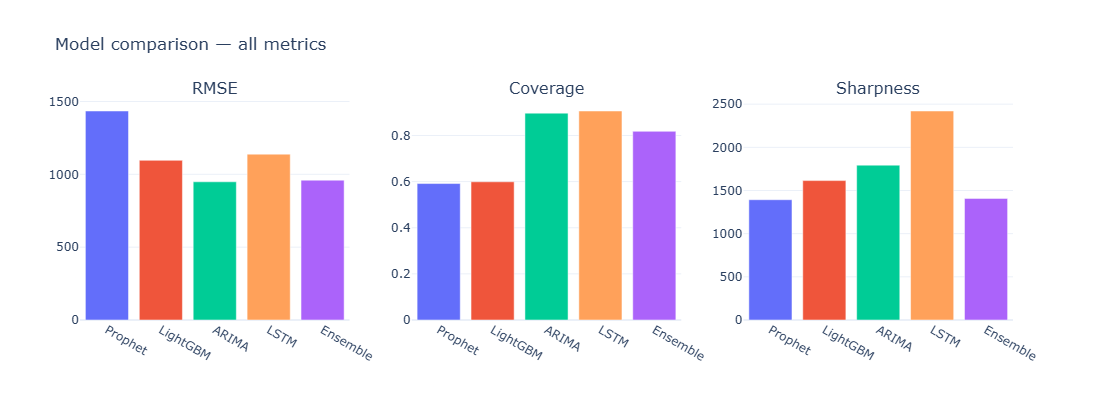

In [3]:
def plot_metrics():
    metrics = ["RMSE", "Coverage", "Sharpness"]
    fig = make_subplots(rows=1, cols=3, subplot_titles=metrics)

    colors = ["rgb(99,110,250)", "rgb(239,85,59)", "rgb(0,204,150)",
              "rgb(255,161,90)", "rgb(171,99,250)"]

    for col_idx, metric in enumerate(metrics):
        fig.add_trace(
            go.Bar(x=results_df.index.tolist(),
                   y=results_df[metric].tolist(),
                   marker_color=colors,
                   showlegend=False),
            row=1, col=col_idx + 1
        )

    fig.update_layout(title="Model comparison — all metrics",
                      template="plotly_white", height=400)
    fig.show()

plot_metrics()

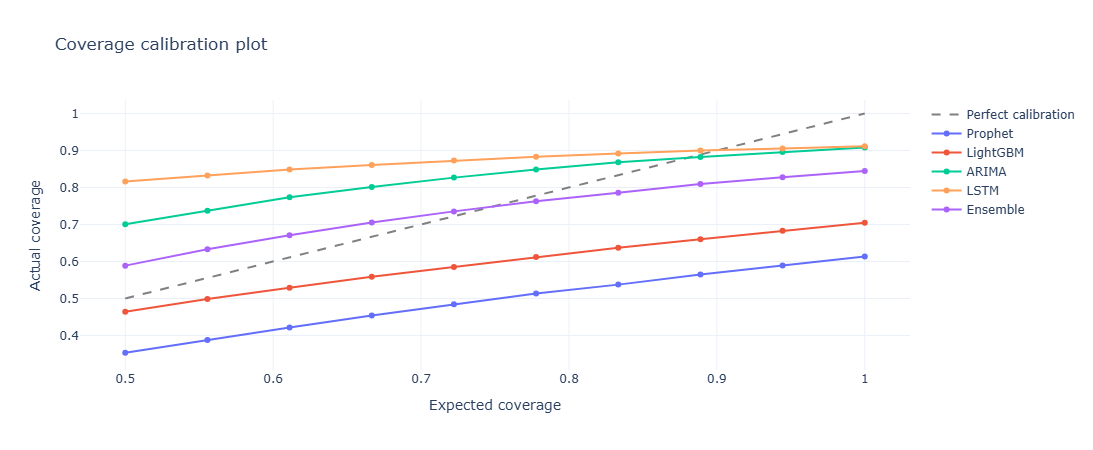

In [4]:
def plot_calibration():
    target_coverages = np.linspace(0.5, 1.0, 10)
    fig = go.Figure()

    fig.add_trace(go.Scatter(x=[0.5, 1.0], y=[0.5, 1.0],
                             mode="lines", line=dict(color="gray", dash="dash"),
                             name="Perfect calibration"))

    colors = {"Prophet": "rgb(99,110,250)", "LightGBM": "rgb(239,85,59)",
              "ARIMA": "rgb(0,204,150)", "LSTM": "rgb(255,161,90)",
              "Ensemble": "rgb(171,99,250)"}

    for name, res in models.items():
        try:
            actual_coverages = []
            for target in target_coverages:
                width   = res["upper"] - res["lower"]
                half    = (width / 2) * (target / 0.95)
                mid     = res["median"]
                inside  = (actuals >= mid - half) & (actuals <= mid + half)
                actual_coverages.append(inside.mean())

            fig.add_trace(go.Scatter(x=target_coverages.tolist(),
                                     y=actual_coverages,
                                     mode="lines+markers",
                                     line=dict(color=colors[name]),
                                     name=name))
        except Exception as e:
            print(f"Skipping {name}: {e}")

    fig.update_layout(title="Coverage calibration plot",
                      xaxis_title="Expected coverage",
                      yaxis_title="Actual coverage",
                      template="plotly_white", height=450)
    fig.show()

plot_calibration()

In [5]:
import plotly.io as pio
from pathlib import Path

CHARTS_DIR = Path("charts")
CHARTS_DIR.mkdir(exist_ok=True)

def save_fan_chart(series_idx=0):
    '''
    Save fan chart for a given series index as HTML file.

    Args:
        series_idx (int): index of series to plot and save

    Raises:
        IndexError: if series_idx is out of range
        OSError: if file cannot be written to disk
    '''
    colors = {
        "Prophet":  ("rgba(99,110,250,0.15)", "rgb(99,110,250)"),
        "LightGBM": ("rgba(239,85,59,0.15)",  "rgb(239,85,59)"),
        "ARIMA":    ("rgba(0,204,150,0.15)",   "rgb(0,204,150)"),
        "LSTM":     ("rgba(255,161,90,0.15)",  "rgb(255,161,90)"),
        "Ensemble": ("rgba(171,99,250,0.15)",  "rgb(171,99,250)")
    }

    if series_idx < 0 or series_idx >= len(series_list):
        raise IndexError(
            f"series_idx {series_idx} out of range.")

    try:
        history = series_list[series_idx][-24:]
        actual  = actuals[series_idx]
        h_steps = list(range(-len(history), 0))
        f_steps = list(range(FORECAST_HORIZON))
    except Exception as e:
        raise RuntimeError(
            f"Failed to extract series data: {e}") from e

    fig = go.Figure()

    try:
        fig.add_trace(go.Scatter(
            x=h_steps, y=history.tolist(), mode="lines",
            line=dict(color="black", width=2), name="History"))
        fig.add_trace(go.Scatter(
            x=f_steps, y=actual.tolist(), mode="lines",
            line=dict(color="black", width=2, dash="dot"),
            name="Actual"))
    except Exception as e:
        raise RuntimeError(
            f"Failed to add base traces: {e}") from e

    for name, res in models.items():
        try:
            fill_col, line_col = colors.get(
                name,
                ("rgba(128,128,128,0.15)", "rgb(128,128,128)"))
            fig.add_trace(go.Scatter(
                x=f_steps,
                y=res["upper"][series_idx].tolist(),
                line=dict(width=0), showlegend=False,
                fillcolor=fill_col, name=name))
            fig.add_trace(go.Scatter(
                x=f_steps,
                y=res["lower"][series_idx].tolist(),
                line=dict(width=0), fill="tonexty",
                fillcolor=fill_col, showlegend=False,
                name=name))
            fig.add_trace(go.Scatter(
                x=f_steps,
                y=res["median"][series_idx].tolist(),
                line=dict(color=line_col, width=1.5),
                name=name))
        except KeyError as e:
            print(f"Missing key for {name}: {e}")
            continue
        except Exception as e:
            print(f"Could not plot {name}: {e}")
            continue

    fig.update_layout(
        title=f"Forecast fan chart — series {series_idx}",
        xaxis_title="Forecast steps (months)",
        yaxis_title="Sales value",
        legend_title="Model",
        template="plotly_white",
        height=450)

    try:
        pio.write_html(
            fig,
            CHARTS_DIR / f"fan_chart_{series_idx}.html")
    except (OSError, IOError) as e:
        print(f"File write error saving fan chart: {e}")
    except Exception as e:
        print(f"Could not save fan chart {series_idx}: {e}")


def save_metrics_chart():
    '''
    Save metrics comparison bar chart as HTML file.

    Raises:
        OSError: if file cannot be written to disk
    '''
    metrics    = ["RMSE", "Coverage", "Sharpness"]
    bar_colors = ["rgb(99,110,250)", "rgb(239,85,59)",
                  "rgb(0,204,150)", "rgb(255,161,90)",
                  "rgb(171,99,250)"]
    fig = make_subplots(rows=1, cols=3,
                        subplot_titles=metrics)

    for col_idx, metric in enumerate(metrics):
        try:
            fig.add_trace(
                go.Bar(x=results_df.index.tolist(),
                       y=results_df[metric].tolist(),
                       marker_color=bar_colors,
                       showlegend=False),
                row=1, col=col_idx + 1)
        except KeyError as e:
            print(f"Column {metric} not found: {e}")
            continue
        except Exception as e:
            print(f"Could not plot {metric}: {e}")
            continue

    fig.update_layout(
        title="Model comparison — all metrics",
        template="plotly_white", height=400)

    try:
        pio.write_html(fig,
                       CHARTS_DIR / "metrics_comparison.html")
    except (OSError, IOError) as e:
        print(f"File write error saving metrics chart: {e}")
    except Exception as e:
        print(f"Could not save metrics chart: {e}")


def save_calibration_chart():
    '''
    Save coverage calibration plot as HTML file.

    Raises:
        OSError: if file cannot be written to disk
    '''
    target_coverages = np.linspace(0.5, 1.0, 10)
    colors = {
        "Prophet":  "rgb(99,110,250)",
        "LightGBM": "rgb(239,85,59)",
        "ARIMA":    "rgb(0,204,150)",
        "LSTM":     "rgb(255,161,90)",
        "Ensemble": "rgb(171,99,250)"
    }
    fig = go.Figure()

    try:
        fig.add_trace(go.Scatter(
            x=[0.5, 1.0], y=[0.5, 1.0], mode="lines",
            line=dict(color="gray", dash="dash"),
            name="Perfect calibration"))
    except Exception as e:
        print(f"Could not add diagonal: {e}")

    for name, res in models.items():
        try:
            actual_coverages = []
            for target in target_coverages:
                try:
                    width  = res["upper"] - res["lower"]
                    half   = (width / 2) * (target / 0.95)
                    mid    = res["median"]
                    inside = ((actuals >= mid - half) &
                              (actuals <= mid + half))
                    actual_coverages.append(
                        float(inside.mean()))
                except Exception as e:
                    actual_coverages.append(float("nan"))
                    continue
            fig.add_trace(go.Scatter(
                x=target_coverages.tolist(),
                y=actual_coverages,
                mode="lines+markers",
                line=dict(color=colors.get(
                    name, "rgb(128,128,128)")),
                name=name))
        except Exception as e:
            print(f"Skipping calibration for {name}: {e}")
            continue

    fig.update_layout(
        title="Coverage calibration plot",
        xaxis_title="Expected coverage",
        yaxis_title="Actual coverage",
        template="plotly_white", height=450)

    try:
        pio.write_html(fig, CHARTS_DIR / "calibration.html")
    except (OSError, IOError) as e:
        print(f"File write error saving calibration chart: {e}")
    except Exception as e:
        print(f"Could not save calibration chart: {e}")


try:
    save_fan_chart(0)
    save_fan_chart(1)
    save_fan_chart(2)
    save_metrics_chart()
    save_calibration_chart()
    print("All charts saved to charts")
except Exception as e:
    print(f"Chart export failed: {e}")

All charts saved to charts
